In [1]:
import os
import re
from dotenv import load_dotenv
import pandas as pd
from google import genai
from google.genai import types
from pydantic import BaseModel, Field 
from huggingface_hub import login
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import pickle
import concurrent.futures
import json
from queue import Queue
from openai import OpenAI
from dotenv import load_dotenv

c:\Users\princ\OneDrive\Desktop\Coding\Python\machine learning\genAI\Private Triage on device\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:


def create_high_recall_snapshot(subject: str, body: str) -> str:
    """
    Slices a long email into a dense layout optimized to preserve urgency cues
    while respecting strict local VRAM and token limits.
    """
    
    clean_body = " ".join(body.split())
    clean_body.replace(">" , "\n")
    
    if len(clean_body) <= 1000:
        return f"Subj: {subject}\nBody: {clean_body}"
        
    # 1. Grab the Head (Highly likely to contain the core intent)
    head = clean_body[:700]
    
    # 2. Grab the Tail (Highly likely to contain deadlines/actions)
    tail = clean_body[-300:]
    
    # 3. Now we don't know what the middle of the message is like so lets use dynamic approach (selecting the portion with urgent looking words and intent)
    urgency_keywords = r"(?i)(asap|urgent|broken|fail|blocker|deadline|critical|override|postpone|cancel)"
    middle_context = ""
    
    # Scan the hidden middle portion of the email
    middle_text = clean_body[700:-300]
    matches = list(re.finditer(urgency_keywords, middle_text))
    
    if matches:
        # Extract a 100-character window around the first critical match found
        first_match = matches[0]
        start = max(0, first_match.start() - 40)
        end = min(len(middle_text), first_match.end() + 60)
        middle_context = f"\n[MID-SIGNAL]: ... {middle_text[start:end]} ..."

    # 4. Construct the dense snapshot
    dense_input = (
        f"Subj: {subject}\n"
        f"Body-Head: {head} ...{middle_context}\n"
        f"Body-Tail: ... {tail}"
    )
    return dense_input

In [3]:
data = load_dataset('Yale-LILY/aeslc')

In [4]:
train = data['train']
test = data['test']
validation = data['validation']

In [5]:
print(train[0])

{'email_body': 'Greg/Phillip,  Attached is the Grande Communications Service Agreement.\nThe business points can be found in Exhibit C.  I Can get the Non-Disturbance agreement after it has been executed by you and Grande.\nI will fill in the Legal description of the property one I have received it.\nPlease execute and send to:  Grande Communications, 401 Carlson Circle, San Marcos Texas, 78666 Attention Hunter Williams.\n<<Bishopscontract.doc>>\n', 'subject_line': 'Service Agreement'}


In [6]:
l = []
for i in train:
    l.append(len(i['email_body']))
count = [1 for i in l if i>200]
print(l[19])

425


In [7]:
print(train[100]) # As we can see that we cant judge a urgency of an email by its size
# So lets take the minimin body size to be 100 and below that will take the 

{'email_body': "> >      There is a bigger picture.\nFor you.... > >      Facts of Life >      1.\nAt least 2 people in this world love you so much they would die for >         you.\n>      2.\nAt least 15 people in this world love you in someway.\n>      3.\nThe only reason anyone would ever hate you is because they want to >         be just like you.\n>      4.\nA smile from you can bring happiness to anyone, even if they don't >         like you.\n>      5.\nEvery night, SOMEONE thinks about you before they go to sleep.\n>      6.\nYou mean the world to someone.\n>      7.\nIf not for you, someone may not be living.\n>      8.\nYou are special and unique.\n>      9.\nSomeone that you don't even know exists, loves you.\n>     10.\nWhen you make the biggest mistake ever, something good comes from it.\n>     11.\nWhen you think the world has turned its back on you, take a look: >         you most likely turned your back on the world.\n>     12.\nWhen you think you have no chance of get

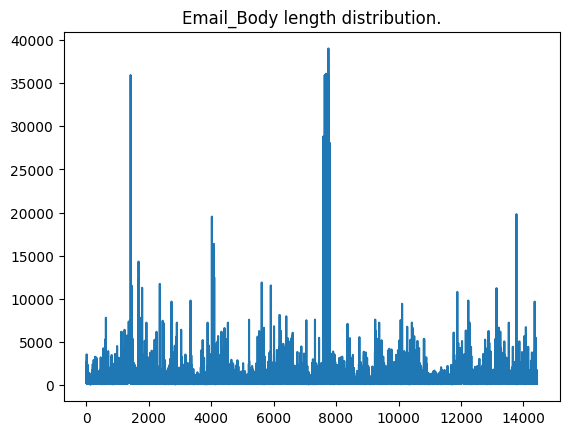

In [8]:
plt.plot(l)
plt.title("Email_Body length distribution.")
plt.show()

In [9]:
BASEMODEL= "google/gemma-4-e4b"
MIN_CHAR=100
MAX_CHAR=1500


In [10]:
load_dotenv(override=True)
API_KEY = 'ollama3'
print(f"Your api key is : {API_KEY[:7]}")
BASE_URL = "http://localhost:11434/v1"  # Example using Groq
MODEL_NAME = "llama3:latest"

client = OpenAI(api_key = API_KEY, base_url = BASE_URL)

categories = ["Work", "Casual", "Home", "Notice", "Social"]


sys_prom = f"""You are a data labeling engine for notification triaging.
Your tast is to analyse raw messages (which can be unformed chat messages or unstructured emails) and you task is to generate two outputs:
1. Intent: A concise, clear, informative, one line summary explaining the practical purpose or requested action.
2. Category: Must be exactly one word from this list: {categories}.

---
Example Input:
Subj: Your approval is requested
Body: I don't know Mog Hue. Please return this request to the person who originated it so that the Manager section can be completed. By including the manager's name, that will help me to identify who this person is, what job they perform and whether or not the request makes sense. I have over 400 people in my group, so without more detail on these requests it is not worth taking my time to approve these. --Sally

Example Output:
Intent: Sally is rejecting an unidentifiable approval request and directing it back to the originator for missing manager details.
Category: Work
---

You must respond only in the following formate. Do not write Intros, Outros or explainations:
Intent: <one-sentence-summary>
Category: <one-word-category>"""




Your api key is : ollama3


In [11]:
def labeling(raw_message):
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role" : "system", "content": sys_prom},
                {"role" : "user" , "content": f"Input_Message: \n{raw_message}"}
            ],
            temperature= 0.1,
            max_tokens= 150
            
        )
        output = response.choices[0].message.content.strip()
        intent_match = re.search(r"Intent:\s*(.*)", output, re.IGNORECASE)
        category_match = re.search(r"Category:\s*(.*)", output, re.IGNORECASE)
        
        if intent_match and category_match:
            intent = intent_match.group(1).strip()
            category = category_match.group(1).strip()
            for cat in categories:
                if cat.lower() in category.lower():
                    category = cat
                    break
        return {
                "message": raw_message,
                "intent_output": intent,
                "category": category,
            }
    except Exception as e:
        print(f"Error processing row: {e}")
    return None
        

In [12]:
import re
from typing import Optional, Dict, Any
from transformers import AutoTokenizer

class TriageItem:
    # Use Gemma 4 / Llama 3.2 tokenizers cleanly
    tokenizer = AutoTokenizer.from_pretrained("google/gemma-4-e4b", trust_remote_code=True)
    
    # Structural triggers for the local model's rationale chain
    THOUGHT_OPEN = "<|channel>thought\n"
    THOUGHT_CLOSE = "\n<channel|>"
    
    def __init__(self, raw_data: Dict[str, Any], max_tokens: int = 512):
        self.sender: str = raw_data.get("sender", "Unknown")
        self.subject: str = raw_data.get("subject", "No Subject")
        self.raw_body: str = raw_data.get("body", "")
        self.intent: str = raw_data.get("intent", "Info")
        self.rationale: str = raw_data.get("rationale", "")
        
        self.max_tokens = max_tokens
        self.prompt: Optional[str] = None
        self.include: bool = False
        
        self.process()

    def clean_whitespace(self, text: str) -> str:
        """Removes layout noise without destroying critical words/codes."""
        if not text:
            return ""
        # Collapse multiple spaces/newlines but keep structural integrity
        text = re.sub(re.compile(r'\s+'), ' ', text)
        return text.strip()

    def process(self):
        """Processes raw text and builds a balanced token-budget constraint prompt."""
        cleaned_body = self.clean_whitespace(self.raw_body)
        
        # Build standard system/user entry structure
        user_input = f"From: {self.sender} | Subj: {self.subject}\nBody: {cleaned_body}"
        
        # Tokenize early to protect character boundaries
        input_tokens = self.tokenizer.encode(user_input, add_special_tokens=False)
        
        # Guardrail: Enforce physical token ceilings for fast local GPU pre-fill
        if len(input_tokens) > self.max_tokens:
            input_tokens = input_tokens[:self.max_tokens]
            user_input = self.tokenizer.decode(input_tokens, skip_special_tokens=True)
            
        # Structure the golden target response (What Gemma 4 must learn to output)
        target_output = (
            f"{self.THOUGHT_OPEN}{self.rationale}{self.THOUGHT_CLOSE}"
            f"INTENT: {self.intent}"
        )
        
        # Assemble the fine-tuning training pair
        self.prompt = f"Instruction: Triage the following notification snapshot.\n\nInput:\n{user_input}\n\nOutput:\n{target_output}"
        self.include = True

    def test_prompt(self) -> str:
        """Returns the prompt sliced exactly where the local agent must begin generation."""
        return self.prompt.split("Output:\n")[0] + "Output:\n"

    def __repr__(self) -> str:
        return f"<TriageItem From={self.sender} Intent={self.intent}>"

In [13]:
train_new = [create_high_recall_snapshot(i['subject_line'], i["email_body"]) for i in train]


In [14]:
print(train_new[:2])

['Subj: Service Agreement\nBody: Greg/Phillip, Attached is the Grande Communications Service Agreement. The business points can be found in Exhibit C. I Can get the Non-Disturbance agreement after it has been executed by you and Grande. I will fill in the Legal description of the property one I have received it. Please execute and send to: Grande Communications, 401 Carlson Circle, San Marcos Texas, 78666 Attention Hunter Williams. <<Bishopscontract.doc>>', 'Subj: Bishops Corner\nBody: Phillip & Keith Attached is the first draw request, I will need some of these funds immediately. I think checks out of Bishops Corner, L.P. may be the easiest, or you can wire money to me and I can write the checks when needed. Please let me know how you wish to handle this and I will proceed. Additionally, it is getting close to closing. I will need to get contracts signed at this point as soon as possible. We can handle this in two ways. I prefer that you elect me as a Vice - President of the General P

In [15]:
CHUNK_SIZE = 500
OUTPUT_FILE = 'triage_dataset.pkl'
def process_batch(batch, executor):
    futures = {executor.submit(labeling, msg): msg for msg in batch}
    results = []
    for future in concurrent.futures.as_completed(futures):
        try:
            res = future.result()
            if res:
                results.append(res)
        except Exception as e:
            print(f"Error: {e}")
    return results

def stream_process(messages):
    generated = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
        for i in range(0, len(messages), CHUNK_SIZE):
            batch = messages[i:i+CHUNK_SIZE]
            print(f"Processing batch {i//CHUNK_SIZE+1} ({len(batch)} items)...")
            batch_results = process_batch(batch, executor)
            generated.extend(batch_results)

            # Save progress incrementally
            df = pd.DataFrame(generated)
            with open(OUTPUT_FILE, "wb") as f:
                pickle.dump(df, f, protocol=pickle.HIGHEST_PROTOCOL)

            print(f"Saved {len(generated)} items so far...")

    return generated

if __name__ == "__main__":
    # Replace with your dataset
    unlabeled = train_new  
    print(f"Streaming {len(unlabeled)} items in chunks of {CHUNK_SIZE}...")
    final_results = stream_process(unlabeled)
    print("✅ All done! Final dataset ready for Hugging Face deployment.")


Streaming 14436 items in chunks of 500...
Processing batch 1 (500 items)...
Saved 500 items so far...
Processing batch 2 (500 items)...
Saved 1000 items so far...
Processing batch 3 (500 items)...
Saved 1500 items so far...
Processing batch 4 (500 items)...
Saved 2000 items so far...
Processing batch 5 (500 items)...
Saved 2500 items so far...
Processing batch 6 (500 items)...
Saved 3000 items so far...
Processing batch 7 (500 items)...
Saved 3500 items so far...
Processing batch 8 (500 items)...
Saved 4000 items so far...
Processing batch 9 (500 items)...
Error processing row: cannot access local variable 'intent' where it is not associated with a value
Error processing row: cannot access local variable 'intent' where it is not associated with a value
Saved 4498 items so far...
Processing batch 10 (500 items)...
Saved 4998 items so far...
Processing batch 11 (500 items)...
Saved 5498 items so far...
Processing batch 12 (500 items)...
Saved 5998 items so far...
Processing batch 13 (500

In [16]:
# import re
# import polars as pl
# from openai import OpenAI

# # 1. ROUTE CLIENT TO YOUR LOCAL HARDWARE ENGINES
# client = OpenAI(
#     base_url="http://localhost:11434/v1",  # Redirects SDK traffic to your own PC
#     api_key="ollama",                      # Required by the SDK but ignored by Ollama
# )

# # Set the exact tag string match of your pulled Ollama model
# MODEL_NAME = "llama3.1:8b"
# output_file = "gemma_triage_dataset.parquet"
# CATEGORIES = ["Work", "Casual", "Home", "Notice", "Social"]

# SYSTEM_PROMPT = """You are a data labeling engine for notification triaging. 
# Analyze raw messages and distill them into two strict outputs:
# Intent: <one-sentence-summary>
# Category: <one-word-category>"""

# # Array container representing your 14,436 source strings
# raw_unlabelled_data = [
#     "Body: I don't know Mog Hue. Please return this request...",
#     # ... all your lines stay right here
# ]

# # Structural resume handling to manage potential hardware drop-outs safely
# try:
#     df_existing = pl.read_parquet(output_file)
#     processed_messages = set(df_existing["raw_message"].to_list())
#     final_rows = df_existing.to_dicts()
#     print(f"Loaded existing data checkpoints. Resuming right from row {len(final_rows)}...")
# except FileNotFoundError:
#     processed_messages = set()
#     final_rows = []

# print(f"Processing local inference execution using standard OpenAI library mapping...")

# for idx, text in enumerate(raw_unlabelled_data):
#     if text in processed_messages:
#         continue

#     try:
#         # Standard OpenAI call format routes cleanly down to Ollama's local runner
#         response = client.chat.completions.create(
#             model=MODEL_NAME,
#             messages=[
#                 {"role": "system", "content": SYSTEM_PROMPT},
#                 {"role": "user", "content": f"Input Message:\n{text}"}
#             ],
#             temperature=0.1,
#             max_tokens=80
#         )
        
#         output_text = response.choices[0].message.content
        
#         # Pull values out with regex
#         intent_match = re.search(r"Intent:\s*(.*)", output_text, re.IGNORECASE)
#         category_match = re.search(r"Category:\s*(.*)", output_text, re.IGNORECASE)
        
#         intent = intent_match.group(1).strip() if intent_match else "N/A"
#         category = category_match.group(1).strip() if category_match else "N/A"
        
#         for cat in CATEGORIES:
#             if cat.lower() in category.lower():
#                 category = cat
#                 break
                
#         final_rows.append({
#             "raw_message": text,
#             "intent": intent,
#             "category": category
#         })
#         processed_messages.add(text)
        
#         # Save structural checkpoint logs every 50 records
#         if len(final_rows) % 50 == 0:
#             print(f"Progress Track: {len(final_rows)} / {len(raw_unlabelled_data)} successfully parsed.")
#             pl.DataFrame(final_rows).write_parquet(output_file)
            
#     except Exception as e:
#         print(f"Error processing index {idx}: {e}")
#         if final_rows:
#             pl.DataFrame(final_rows).write_parquet(output_file)
#         break

# # Final clean parquet file compilation block
# if final_rows:
#     pl.DataFrame(final_rows).write_parquet(output_file)
#     print(f"\n🎉 Done! Local compilation complete. Data matrix exported directly to {output_file}")

In [23]:
import pickle
import pandas as pd

# Define the exact same file name you used to save it
OUTPUT_FILE = "triage_dataset.pkl"

try:
    # Open and load the pickle file
    with open(OUTPUT_FILE, "rb") as f:
        df = pickle.load(f)
    
    # Print the total number of processed rows
    print(f"📊 Total Rows Processed successfully: {len(df)}")
    print("-" * 50)
    
    # Show the first 5 rows to check the content
    print("👀 First 5 rows of your dataset:")
    print(df.head())
    
    print("-" * 50)
    # Check the distribution of your categories to see how Llama classified them
    print("🗂️ Category Distribution Breakdown:")
    print(df['category'].value_counts())

except FileNotFoundError:
    print(f"❌ Error: Could not find '{OUTPUT_FILE}' in this directory. Make sure the path matches.")
except Exception as e:
    print(f"❌ An error occurred while loading the data: {e}")

📊 Total Rows Processed successfully: 14434
--------------------------------------------------
👀 First 5 rows of your dataset:
                                             message  \
0  Subj: Bishops Corner\nBody: Phillip & Keith At...   
1  Subj: Service Agreement\nBody: Greg/Phillip, A...   
2  Subj: Internet Banking\nBody-Head: Your Intern...   
3  Subj: Internet Banking\nBody-Head: To our IBS ...   
4  Subj: SMEs for expert stories\nBody: Phillip G...   

                                       intent_output category  
0  Greg requests funds for Bishops Corner, LP, an...     Work  
1  Execute and return a Service Agreement with at...     Work  
2  Set up internet banking accounts with new logi...     Work  
3  The bank apologizes for internet banking issue...     Work  
4  Phillip is requested to identify SMEs for expe...     Work  
--------------------------------------------------
🗂️ Category Distribution Breakdown:
category
Work      11593
Social     1517
Casual      851
Notice   

In [2]:
df = pd.read_pickle('triage_dataset.pkl')

In [31]:
sample = []
for i in range(0, 400):
    if df['category'][i] == 'Social':
        sample.append((df['message'][i],
        df['intent_output'][i],
        df['category'][i]))
    if len(sample) == 20:
        break

In [32]:
sample

[('Subj: stuff\nBody: i hpe thingsa re ok for you.obviously a shit load of rumours circulating . we both know youll be ok personally but cant be fun. if i can help you know where im at. be cool',
  'Checking in and offering support amidst rumors.',
  'Social'),
 ("Subj: hi\nBody: Hey there. We are going to be at Front Porch today if you aren't busy later. You are invited to stop by and wear my necklace if you want. Has your week been better than last week? Talk to you soon. Kim",
  'Kim is inviting someone to meet up at Front Porch and discuss their week.',
  'Social'),
 ("Subj: Small world!\nBody-Head: Hey John! How are you?? I've been following the Enron story closely, which means I've thought of you a lot recently. I hope things are going well, despite the uncertainty. I ran into someone from our Enron days today, which made me think of a funny story. Do you remember when John Mee tried to eat 8 Big Macs and hurled instead? John was talking to my boss, Chuck Clough, today, who he's 

In [56]:
dataset = [
    (
        "Subj: stuff\nBody: i hpe thingsa re ok for you.obviously a shit load of rumours circulating . we both know youll be ok personally but cant be fun. if i can help you know where im at. be cool",
        "Checking in and offering support amidst rumors.",
        "Social"
    ),
    (
        "Subj: hi\nBody: Hey there. We are going to be at Front Porch today if you aren't busy later. You are invited to stop by and wear my necklace if you want. Has your week been better than last week? Talk to you soon. Kim",
        "Kim is inviting someone to meet up at Front Porch and discuss their week.",
        "Social"
    ),
    (
        "Subj: Small world!\nBody-Head: Hey John! How are you?? I've been following the Enron story closely, which means I've thought of you a lot recently. I hope things are going well, despite the uncertainty. I ran into someone from our Enron days today, which made me think of a funny story. Do you remember when John Mee tried to eat 8 Big Macs and hurled instead? John was talking to my boss, Chuck Clough, today, who he's known since childhood and is a mentor of sorts. When he got off the phone, Chuck told me who he was talking to and the name John Mee struck me as familiar. I asked Chuck if he was a big kid who'd gone to Harvard and he said yes. So I tell him the Big Mac story and Chuck picks up the phone and calls John to ask ...\nBody-Tail: ... member off the top of my head. They both work for a weather trading firm in the Northeast now, with Lynda Clemmons. Well, gotta run to the gym - been putting it off as long as I could today. I really do hope you're doing well. Please drop me a line when you aren't trading up a storm... Warm regards,",
        "John is sharing a funny story about John Mee and catching up with his friend.",
        "Social"
    ),
    (
        "Subj: Contact\nBody: I left a message earlier with your assistant. My contact information is below, please touch base with me as soon as possible. I am working on a project that is very pressing.",
        "Request to initiate urgent communication and collaboration.",
        "Social"
    ),
    (
        "Subj: SAVE $15 on Bibi Magazine's New Year's Eve Party.....Just mention  \"PURE ENERGY\"!\nBody-Head: ========================================================= PURE NRG's UPCOMING CALENDAR OF EVENTS * December 31 (Monday) - Westin Hotel - Bibi Magazine's New Year's Eve Party [SAVE $15 with Pure NRG] * February 2 (Saturday) - Valentine's Speed-Dating Mixer via Pure NRG & MeraPyar.com ========================================================= Mention PURE ENERGY whenever you buy your New Year's Eve tickets to Bibi Magazine's Party at the Westin Galleria Hotel, and get a $15 DISCOUNT off of the Regular Rates. No matter who you buy them from, you must ask for the \"Pure Energy\" discount in order to get the CHEAPEST TICKETS AVAILABLE. To purchase your tickets or for any questions, send email to PUR ...\nBody-Tail: ... , Bhangra and Latin Music Dancing with DJ Nitro Roaming Photographers Other Surprises ========================================================= Ticket Prices: Pure NRG Discounted Rate $110 per person [SAVE $15 by mentioning \"PURE ENERGY\"] Regular Price $125 per person Reserved Tables $150 per person",
        "Buy discounted tickets to Bibi Magazine's New Year's Eve Party at the Westin Galleria Hotel.",
        "Social"
    ),
    (
        "Subj: Compelling small cap investment opportunity\nBody: ***************************************************************** As a registered Multex Investor member, we will occasionally contact you with special opportunities provided by our partners. To unsubscribe to this or any other exclusive offers, please see the bottom of this message. *****************************************************************",
        "A registered investor is being offered a small-cap investment opportunity.",
        "Social"
    ),
    (
        "Subj: Lunch\nBody: Since Mr. Bass didn't follow through on our social engagement, I thought I would do so. Is anyone interested in lunch? Is tomorrow too early for you all or should we shoot for next week? Mr. Hull and I are both available tomorrow. You guys let me know. We'll have to go dutch (no more expense report) or one of you UBS people with your big bonuses will have to pick it up! Let me know.",
        "Organizing a social lunch invitation for colleagues.",
        "Social"
    ),
    (
        "Subj: Hey can I bum a Golf Ball\nBody-Head: See dear, sometimes you get what you ask for. Love you-L A bum, who obviously has seen more than his share of hard times, approaches a well dressed gentleman on the street. \"Hey, Buddy, can you spare two dollars?\" The well-dressed gentleman responds, \"You are not going to spend in on liquor are you?\" \"No, sir, I don't drink,\" retorts the bum. \"You are not going to throw it away in some crap game, are you?\" asks the gentleman. \"No way, I don't gamble,\" answers the bum. \"You wouldn't waste the money at a golf course for greens fees, would you?\" asks the man. \"Never,\" says the bum, \"I don't play golf.\" The man asks the bum if he would like to come home with him for a home cooked meal. The bum a ...\nBody-Tail: ...  While they are heading for the man's house, the bum's curiosity gets the better of him. \"Isn't your wife going to be angry when she sees a guy like me at your table?\" \"Probably,\" says the man, \"but it will be worth it. I want her to see what happens to a guy who doesn't drink, gamble or play golf.\"",
        "A well-dressed gentleman invites a homeless person to dinner to show his wife the positive impact of not engaging in vices.",
        "Social"
    ),
    (
        "Subj: Good Morning\nBody: Hi Eric, It looks like Enron employees have an enterprising spirit according to the H. Chronicle. Ebay is saturated with Enron goodies. This is quite amusing. Sorry about tonight and we will miss you on your birthday. We will celebrate whenever you wish, just let us know. If you change your mind about tomorrow, email me. Donnita and Jason are coming over for dinner. We would love for you to come. Have a wonderful day. LU-M",
        "Eric is invited to join friends for dinner and birthday celebration.",
        "Social"
    ),
    (
        "Subj: A friend\nBody-Head: A simple friend has never seen you cry. A real friend has shoulders soggy from your tears. A simple friend doesn't know your parents' first names. A real friend has their phone numbers in his address book. A simple friend brings a bottle of wine to your party. A real friend comes early to help you cook and stays late to help you clean. A simple friend hates it when you call after he has gone to bed. A real friend asks you why you took so long to call. A simple friend seeks to talk with you about your problems. A real friend seeks to help you with your problems. A simple friend wonders about your romantic history. A real friend could blackmail you with it. A simple friend, when visiting, acts ...\nBody-Tail: ... pens your refrigerator and helps himself. A simple friend thinks the friendship is over when you HAVE an argument. A real friend knows that it's not a friendship until after you've had a fight. A simple friend expects you to always be there for them. A real friend expects to always be there for you!",
        "The message distinguishes between a \"simple\" and a \"real\" friend, highlighting the characteristics of a true and supportive friend.",
        "Social"
    ),
    (
        "Subj: Birthday\nBody: Hi Eric, Sorry but Dad can't make it Thursday night. Would dinner here on Friday be o.k. with you? Dad suggested games, etc., and I wanted to bake a birthday cake. We can either order in or I would love to cook anything you would like. It's up to you. Let me know. Have a great day. Love, Mom",
        "Eric is invited for his dad's birthday dinner on Friday with options to order in or cook.",
        "Social"
    ),
    (
        "Subj: Happy Birthday\nBody: Hi Eric, I know this weekend will be a busy one for you but I just wanted to wish you an early Happy Birthday. Hope all is well with you and Shanna. I hope to see you in a few months. Love Aunt Bonnie",
        "Aunt Bonnie wishes Eric an early happy birthday.",
        "Social"
    ),
    (
        "Subj: Honeymoon Itinerary\nBody: Attached is the path to the honeymoon package we chose. Let me know if you need anything else. Thanks again for doing this...it means a great deal to us both. Jason",
        "Confirming and thanking someone for planning their honeymoon itinerary.",
        "Social"
    ),
    (
        "Subj: venture\nBody: Eric - it was good to see you again after all this time. Sounds like you are well on your way to making things happen for yourself. Anyway - I am definitely new in this town as far as I am concerned. So - I don't want to burden you with spending any time with my sorry ass - but to the extent that you want to grab your girlfriend and a friend of hers - I would always be willing to venture out. I definitely need to meet some new people. In any event, I'm sure that we will run into each other plenty at the gym, etc. Talk to you soon Eric.",
        "The writer is inviting Eric to socialize with his girlfriend and a friend.",
        "Social"
    ),
    (
        "Subj: Tuxedos for the wedding\nBody: I wanted to try to set a day where we can all get fitted for our Tuxedos for the wedding. I would like to get it done sometime in the very near future. It should not take mor than a couple of hours. Would you all be available Saturday December 29? Please let me know if this date does not work. Jason",
        "Jason is organizing a Tuxedo fitting session for wedding attendees on December 29.",
        "Social"
    ),
    (
        "Subj: A Christmas message from Bruce Eberle\nBody: \"I bring you good news of great joy that will be for all the people. Today in the town of David a Savior has been born to you; he is Christ the Lord.\" Luke 2:10, 11 Dear Americans, As we prepare to celebrate the birthday of Jesus Christ, let me take this opportunity to wish you a joyous Christmas celebration and peace in the New Year. May the true meaning of Christmas, God's gift of His own son as our savior, be yours in this holiday season and throughout the New Year. May God continue to bless our nation and its leaders, especially President George Bush, as we confront an enemy who hates everything this nation stands for -- peace,",
        "Wishing Americans a joyous Christmas celebration and peace in the New Year.",
        "Social"
    ),
    (
        "Subj: Thank you is nice. But cash is even better.\nBody: Thank you is nice. But cash is even better. Happy Holidays from SBC! We wanted to do more than just say thanks to our customers who view",
        "SBC expresses gratitude and offers a reward to their customers for viewing.",
        "Social"
    ),
    (
        "Subj: The Washington Times National Weekly Edition\nBody-Head: Dear Americans, When I send out a breaking news update from MillionsofAmericans.com many people write back to me thanking me for the information and asking me about my sources. Like Rush Limbaugh, many times, I refer to the Washington Times often. I find The Washington Times National Weekly Edition to be well written and right on top of the issues. In fact, The Times has repeatedly scooped all other news sources on major national issues like the Clinton scandals. Perhaps more important, The Washington Times National Weekly Edition reports stories the liberal news media intentionally ignores because it does not fit their version of the news. If you want to stay truly informed and get the fact ...\nBody-Tail: ...  what's really happening in the world, I strongly suggest that you read The Washington Times National Weekly Edition. I could not do without The Times to combat the liberalism of the Washington Post. Now there's a way that you too can have what I do -- by reading the Washington Times National Weekly",
        "The author recommends reading The Washington Times National Weekly Edition for accurate and unbiased news.",
        "Social"
    ),
    (
        "Subj: Bigger picture for you (of you!)\nBody-Head: > > There is a bigger picture. For you.... > > Facts of Life > 1. At least 2 people in this world love you so much they would die for > you. > 2. At least 15 people in this world love you in someway. > 3. The only reason anyone would ever hate you is because they want to > be just like you. > 4. A smile from you can bring happiness to anyone, even if they don't > like you. > 5. Every night, SOMEONE thinks about you before they go to sleep. > 6. You mean the world to someone. > 7. If not for you, someone may not be living. > 8. You are special and unique. > 9. Someone that you don't even know exists, loves you. > 10. When you make the biggest mistake ever, something good comes from it. > 11.  ...\nBody-Tail: ... r or later, you will get it. > 13. Always remember the compliments you received. Forget about the rude > remarks. > 14. Always tell someone how you feel about them; you will feel much > better when they know. > 15. If you have a great friend, take the time to let them know that > they are great. > >",
        "The message is an inspirational and motivational reminder of one's value and importance in the world.",
        "Social"
    ),
    (
        "Subj: Bouche\nBody: I was wondering if ya'll wanted to have a happy hour on Friday for Tim and Louise in honor of their recent engagement. Do you have any ideas on places to go? Let me know",
        "Organize a happy hour celebration for Tim and Louise's engagement.",
        "Social"
    ),
    (
        "Subj: Weekend Plans\nBody: Hey Dave, are we still on for golf this Saturday? The weather looks perfect. Let me know if we need to secure a tee time early or if you have it handled.",
        "Checking in to confirm golf plans for Saturday.",
        "Social"
    ),
    (
        "Subj: Dinner tonight?\nBody: Hey Sarah, a few of us are heading over to the Downtown Bistro around 7 PM after the trading floor closes. Let me know if you want to join us!",
        "Inviting Sarah to join colleagues for dinner at Downtown Bistro.",
        "Social"
    ),
    (
        "Subj: RE: Fantasy Football League\nBody: Guys, the draft is set for next Tuesday at 8 PM. Make sure your player rankings are locked in. Winner takes the cash pool, no exceptions this year.",
        "Confirming the schedule and guidelines for the upcoming fantasy football draft.",
        "Social"
    ),
    (
        "Subj: Baby Shower!\nBody-Head: Hi everyone, as you know, Michelle is expecting her first baby next month! We are putting together a small surprise baby shower in the conference room this Friday at 3 PM. We've got cake and drinks covered, but if you'd like to chip in for the main gift (we are looking at a premium stroller), please drop by my desk ...\nBody-Tail: ... or send a note with your contribution. Let's make this special for her before she goes on maternity leave! See you all there.",
        "Inviting team members to a surprise baby shower and organizing a group gift.",
        "Social"
    ),
    (
        "Subj: Super Bowl Party\nBody: Just a reminder that the party starts at 5 PM at my place this Sunday. Bring your favorite beverage, I will supply the wings and chips. Let me know if you can make it.",
        "Inviting friends to a Super Bowl party and providing details.",
        "Social"
    ),
    (
        "Subj: Happy Anniversary!\nBody: Hey Mike and Jenny, wishing you both a fantastic anniversary! Hard to believe it has been 5 years already. Hope you have a wonderful evening celebrating.",
        "Congratulating Mike and Jenny on their wedding anniversary.",
        "Social"
    ),
    (
        "Subj: Quick question\nBody: Hey man, do you still have that contact info for the catering company we used last summer? I need to book someone for a family gathering next month. Thanks!",
        "Requesting contact information for a catering service previously used.",
        "Social"
    ),
    (
        "Subj: Retirement Party for Bob\nBody-Head: Hi Team, Bob is officially hanging up his boots after 22 years of dedicated service with the firm. To honor his incredible career, we are hosting a farewell gathering at the Pavilion Club next Thursday starting at 6:30 PM. There will be an open bar for the first hour and a presentation ...\nBody-Tail: ... around 7:30 PM. Please RSVP by Tuesday morning so we can finalize the headcount with the venue. Hope to see you all there to give Bob a proper send-off!",
        "Organizing a retirement farewell celebration for a long-term colleague.",
        "Social"
    ),
    (
        "Subj: Coffee crawl\nBody: Hey, running down to Starbucks in 10 minutes if anyone wants to escape their cubicle for a bit. Let me know your order or just walk down with me.",
        "Inviting colleagues to take a quick coffee break.",
        "Social"
    ),
    (
        "Subj: Housewarming party next weekend\nBody: We finally finished unpacking! Come check out the new place next Saturday anytime after 4 PM. Casual dress, kids are welcome. Let us know if you can drop by.",
        "Inviting friends to a casual housewarming party at a new home.",
        "Social"
    ),
    (
        "Subj: Concert tickets\nBody: Hey, I have two extra tickets to the Dave Matthews Band concert this Friday night because Jim can't make it. Face value. Let me know if you are interested.",
        "Offering extra concert tickets for sale due to a scheduling conflict.",
        "Social"
    ),
    (
        "Subj: Happy Holidays!\nBody: Just wanted to send a quick note wishing you and your family a safe, peaceful, and joyful holiday season. Looking forward to catching up properly in the new year.",
        "Sending warm holiday greetings and expressing a desire to catch up soon.",
        "Social"
    ),
    (
        "Subj: Running club tomorrow\nBody: Hey team, weather looks solid for tomorrow morning. Meeting at the park entrance at 6:30 AM for our usual 5k loop. Don't hit snooze!",
        "Reminding running club members of the scheduled morning run.",
        "Social"
    ),
    (
        "Subj: Great seeing you\nBody: Hey Mark, just wanted to say it was awesome catching up at the conference yesterday. Let's not wait another three years to grab a beer. Travel safe back home.",
        "Expressing appreciation for catching up with an old friend at a conference.",
        "Social"
    ),
    (
        "Subj: Moving sale this Sunday\nBody: Hey guys, clearing out the garage before the big move. Got a lot of good tools, camping gear, and electronics up for grabs. Stop by starting at 9 AM if you want first dibs.",
        "Inviting friends to a garage sale ahead of a relocation.",
        "Social"
    ),
    (
        "Subj: Welcome back!\nBody: Hey Jeff, heard you just got back from your safari trip. Can't wait to see the pictures and hear all the stories. Let's grab lunch this week so you can tell me all about it.",
        "Welcoming Jeff back from vacation and suggesting a lunch meetup to hear about the trip.",
        "Social"
    ),
    (
        "Subj: Friday Night Drinks\nBody: Is anyone up for hitting the pub down the street after the final reports are filed? I think we all deserve a cold drink after this chaotic week. Let me know.",
        "Proposing a casual after-work gathering at a local pub to unwind.",
        "Social"
    ),
    (
        "Subj: BBQ at my place\nBody: Fire is getting lit at 2 PM on Sunday. Steaks, burgers, and cold drinks are covered. Just bring yourself and a good appetite. Let me know if you're in.",
        "Inviting friends over for a Sunday afternoon backyard barbecue.",
        "Social"
    ),
    (
        "Subj: Joke of the day\nBody: Why don't scientists trust atoms? Because they make up everything! Hope that gives you a little chuckle during your busy afternoon. Have a good one!",
        "Sharing a lighthearted joke to brighten a colleague's day.",
        "Social"
    ),
    (
        "Subj: Graduation Celebration!\nBody-Head: Dear Family and Friends, we are incredibly proud to announce that Sarah is graduating with honors from UT Austin this semester! To celebrate this milestone, we are hosting a dinner party at the Magnolia Room on June 14th at 7:00 PM. It has been a long journey, and your support ...\nBody-Tail: ... meant everything to her along the way. Please join us for an evening of food, memories, and celebration. RSVP by June 1st.",
        "Inviting family and friends to a dinner celebrating a college graduation.",
        "Social"
    ),
    (
        "Subj: Congratulations on the new addition!\nBody: Hey Chris, heard the amazing news about the baby! Big congrats to you and Emily. Hope mom and newborn are doing fantastic. Get some sleep while you can!",
        "Congratulating a friend on the birth of their new baby.",
        "Social"
    ),
    (
        "Subj: Poker night this Thursday\nBody: Usual stakes, usual location. Starting at 7:30 PM sharp. Let me know by tomorrow night if you are sitting out so I can get an accurate count for cards.",
        "Confirming details and gathering RSVPs for a regular poker night.",
        "Social"
    ),
    (
        "Subj: RE: Ski Trip Lodging\nBody: Hey everyone, I locked in the cabin for the first weekend of February. Total came out to $120 per person. Please Venmo or PayPal me by Friday so I can clear the card.",
        "Requesting payment reimbursement from friends for a booked ski cabin.",
        "Social"
    ),
    (
        "Subj: Quick check-in\nBody: Hey grandma, just wanted to call and see how you're feeling after your doctor's appointment yesterday. Give me a ring whenever you have a free minute, love you!",
        "Checking in on a family member's health after a medical appointment.",
        "Social"
    ),
    (
        "Subj: Halloween Costumes\nBody: Hey guys, are we doing a group theme for the office party this year or is everyone flying solo? We need to coordinate soon if we're doing the Star Wars theme.",
        "Inquiring about coordinating group costumes for an upcoming office party.",
        "Social"
    ),
    (
        "Subj: Weekend hike?\nBody: Weather looks pristine for Sunday. Thinking of hitting the Green Mountain trail around 8 AM before it gets too hot. Let me know if anyone wants to carpool.",
        "Proposing a weekend hiking trip and offering carpool options.",
        "Social"
    ),
    (
        "Subj: Recipe from last night\nBody: Hey Laura, here is that spinach dip recipe you asked for. Super easy to make: just mix spinach, cream cheese, sour cream, and garlic powder, then bake at 350 for 20 mins. Enjoy!",
        "Sharing a requested appetizer recipe with a friend.",
        "Social"
    ),
    (
        "Subj: Tailgating details\nBody-Head: Hey crew, spots are filling up fast for the game this weekend. We secured plot 4B right next to the stadium entrance. Look for the massive blue tent and the Enron flag flying high. We will be firing up the grill around 11 AM for the 3:30 PM kickoff. Bring whatever ...\nBody-Tail: ... you want to throw on the grill and your own beverages. Let's have a great turnout. See you there!",
        "Coordinating logistics and location details for a football tailgating event.",
        "Social"
    ),
    (
        "Subj: Happy Birthday buddy!\nBody: Hey man, just wanted to wish you a massive happy birthday! Hope you have an awesome day and get celebrated properly. Let's grab a drink this weekend to toast.",
        "Wishing a close friend a happy birthday and suggesting a celebration.",
        "Social"
    ),
    (
        "Subj: Road trip playlist\nBody: Hey guys, setting up a collaborative Spotify playlist for our drive to Colorado next week. Drop your favorite driving tracks in there so we don't fall asleep!",
        "Requesting song contributions for a collaborative road trip playlist.",
        "Social"
    ),
    (
        "Subj: Local theater tonight\nBody: Hey, I have an extra ticket to the community play tonight at 8 PM. It's supposed to be a really funny comedy. Let me know if you're free and want to go.",
        "Inviting a friend to a local theater production with an extra ticket.",
        "Social"
    ),
    (
        "Subj: Thanksgiving Dinner Coordination\nBody: Hi family, just wanted to organize who is bringing what next week. I have the turkey and stuffing handled. Let me know what sides or desserts you plan to bring.",
        "Coordinating food assignments for a family Thanksgiving dinner.",
        "Social"
    ),
    (
        "Subj: Trivia Night Tuesday\nBody: Hey team, we took third place last week, so we need to step it up! Meeting at the usual pub at 7 PM to grab a good table before trivia starts at 7:30. See ya.",
        "Organizing the weekly meetup for a pub trivia team.",
        "Social"
    ),
    (
        "Subj: Book club selection\nBody: Hey everyone, the votes are in for next month's read. We will be discussing 'The Great Gatsby' at Elena's place on the last Thursday of the month. Happy reading!",
        "Announcing the monthly book club selection and meeting details.",
        "Social"
    ),
    (
        "Subj: Safe travels!\nBody: Hey Tom, just wanted to wish you a safe flight to Europe tonight. Have an absolutely incredible vacation, take tons of photos, and don't think about work for a second!",
        "Wishing a colleague a safe flight and an enjoyable vacation.",
        "Social"
    ),
    (
        "Subj: Pool party this Saturday\nBody: Sun is out and the pool is warm! Come over around 1 PM for swimming and snacks. Bring towels and sunscreen. Let me know if you can make it.",
        "Inviting friends to a weekend pool party and reminding them of essentials.",
        "Social"
    ),
    (
        "Subj: New dog!\nBody: Hey guys, we finally adopted a puppy today! His name is Buster and he's a golden retriever mix. Stop by this weekend if you want to come over and meet him.",
        "Sharing news of a new pet adoption and inviting friends to visit.",
        "Social"
    ),
    (
        "Subj: Fantasy Basketball setup\nBody-Head: Hey all, it's that time of the year again. Setting up the official fantasy basketball league for the office. Registration deadline is this Friday. It's a $20 buy-in with standard head-to-head scoring rules. If you participated last year, your spot is held, but you still need to ...\nBody-Tail: ... confirm your entry. Reply directly to this email to get the league invite link. Let's make it a competitive season!",
        "Inviting colleagues to join the office fantasy basketball league.",
        "Social"
    ),
    (
        "Subj: Happy Mother's Day!\nBody: Hi Mom, just wanted to say Happy Mother's Day! Thank you for always being there for me and supporting me through everything. Can't wait to see you next weekend.",
        "Sending affectionate Mother's Day wishes and planning a visit.",
        "Social"
    ),
    (
        "Subj: Casual tennis match?\nBody: Hey Peter, are you free for a casual hit on the tennis courts this Thursday after work? Say around 5:30 PM? Let me know if that time works for you.",
        "Inviting a friend to play a casual game of tennis after work.",
        "Social"
    ),
    (
        "Subj: New Year's Eve plans\nBody: Hey group, what are we doing for New Year's Eve this year? Are we hosting a house party or trying to go downtown? Let's figure something out before everything books up.",
        "Initiating a group discussion to plan activities for New Year's Eve.",
        "Social"
    ),
    (
        "Subj: Left my jacket\nBody: Hey Mike, I think I accidentally left my black leather jacket at your apartment during the party last night. Let me know if you find it anywhere near the couch.",
        "Inquiring about a missing personal item left behind at a friend's apartment.",
        "Social"
    ),
    (
        "Subj: Welcome to the neighborhood!\nBody: Hi there, noticed you just moved in down the street! Just wanted to say welcome to the block. If you ever need recommendations for local spots, don't hesitate to ask.",
        "Welcoming a new neighbor to the area and offering local advice.",
        "Social"
    ),
    (
        "Subj: Board game night\nBody: Hey guys, hosting a board game night this Friday at 7 PM. Got a couple of new strategic games to try out. I'll provide pizza, just bring your own drinks.",
        "Inviting friends over for a Friday evening board game night.",
        "Social"
    ),
    (
        "Subj: RE: Wedding RSVP\nBody: Hey Sarah, just sending over our official RSVP for the wedding. Both Mark and I will be able to make it, and we both selected the salmon option. Can't wait!",
        "Confirming attendance and meal choices for a wedding invitation.",
        "Social"
    ),
    (
        "Subj: Congratulations on the promotion!\nBody: Hey Kevin, just saw the announcement on the company board. Huge congrats on making Managing Director! It is thoroughly deserved after all your hard work.",
        "Congratulating a coworker on a significant career promotion.",
        "Social"
    ),
    (
        "Subj: Camping trip logistics\nBody-Head: Alright team, here is the breakdown for our weekend camping trip. We need to leave the city by 4 PM on Friday to beat the traffic. John is handling the tents, Kelly is bringing the large cooler, and I am packing the dry firewood. Make sure to pack extra layers as it gets ...\nBody-Tail: ... down into the 40s at night near the lake. Double-check the gear list and let me know if you have any questions.",
        "Coordinating equipment assignments and schedule details for a camping trip.",
        "Social"
    ),
    (
        "Subj: Happy Father's Day!\nBody: Hey Dad, wishing you a very happy Father's Day! Thanks for being the best role model I could ask for. Hope you get to relax and enjoy your day on the golf course.",
        "Sending Father's Day greetings and well wishes for a relaxing day.",
        "Social"
    ),
    (
        "Subj: Concert tonight?\nBody: Hey, a local indie band is playing at the underground lounge tonight around 9 PM. Tickets are only ten bucks at the door. Let me know if you want to tag along.",
        "Inviting a friend to a casual local live music performance.",
        "Social"
    ),
    (
        "Subj: Beach day this Sunday\nBody: Hey crew, driving down to the coast this Sunday morning. Leaving around 8 AM to secure a good spot on the sand. Let me know if you want to hitch a ride with us.",
        "Proposing a Sunday beach trip and offering transportation to friends.",
        "Social"
    ),
    (
        "Subj: Thinking of you\nBody: Hey Uncle Bob, just wanted to send a quick note to let you know we are thinking about you. Hope you are recovering well from the surgery. Sending you lots of love.",
        "Sending warm wishes and support to a family member recovering from surgery.",
        "Social"
    ),
    (
        "Subj: Housewarming gift ideas?\nBody: Hey Rachel, going to Tim's housewarming party this weekend. Do you have any good ideas for a gift, or do you want to split the cost on a nice espresso machine?",
        "Consulting a friend regarding gift ideas for a housewarming party.",
        "Social"
    ),
    (
        "Subj: Weekend brunch\nBody: Hey ladies, let's do brunch this Sunday at 11 AM at the Garden Cafe. It's been way too long since we all had a proper catch-up. Let me know if you can make it!",
        "Organizing a weekend brunch meetup for a group of friends.",
        "Social"
    ),
    (
        "Subj: Football tickets available\nBody: Hey, I won't be able to make the game this weekend due to a family conflict. Selling my two lower-bowl season tickets if anyone wants them. Let me know ASAP.",
        "Offering football tickets for sale due to a scheduling conflict.",
        "Social"
    ),
    (
        "Subj: Happy Thanksgiving!\nBody: Wishing you and your loved ones a beautiful Thanksgiving filled with great food, family warmth, and wonderful memories. Enjoy the holiday break!",
        "Sending warm holiday wishes for a happy and peaceful Thanksgiving.",
        "Social"
    ),
    (
        "Subj: Happy Holidays from the leadership team\nBody-Head: Dear Team, as we look back on an exceptional year of milestones and achievements, we want to express our deepest gratitude for your hard work and dedication. To celebrate our collective success, the office will be closing early this Friday at 1 PM for the holiday break. May this season bring ...\nBody-Tail: ... peace, happiness, and well-deserved rest to you and your families. We look forward to an even brighter year ahead.",
        "Corporate announcement expressing holiday gratitude and early closure.",
        "Social"
    ),
    (
        "Subj: Movie night?\nBody: Hey, that new sci-fi blockbuster is finally out in theaters. Thinking of catching the 7:15 PM showing tonight at the multiplex. Let me know if you want to join.",
        "Inviting a friend to watch a newly released movie at the theater.",
        "Social"
    ),
    (
        "Subj: Ice cream run\nBody: Taking a break from editing these spreadsheets. Heading to the artisanal ice cream shop across the street if anyone wants a scoop. Leaving in 5 mins!",
        "Inviting colleagues to join a brief afternoon ice cream break.",
        "Social"
    ),
    (
        "Subj: Welcome to the team lunch\nBody: Hey all, let's welcome our new analyst, Amanda, with a team lunch this Thursday at 12:30 PM at the Italian Trattoria down the block. Management is picking up the tab!",
        "Organizing a welcome lunch for a new team member at a local restaurant.",
        "Social"
    ),
    (
        "Subj: Left my sunglasses\nBody: Hey Amanda, I think I accidentally left my aviator sunglasses in your car when you dropped me off last night. Let me know if you spot them on the passenger side.",
        "Inquiring about a personal item left behind in a friend's vehicle.",
        "Social"
    ),
    (
        "Subj: Weekend bike ride\nBody: Planning a scenic 20-mile bike ride along the river trail this Saturday morning. Keeping a moderate pace. Meeting at the trailhead at 8:00 AM if anyone wants to join.",
        "Inviting friends to a weekend bicycle ride along a scenic trail.",
        "Social"
    ),
    (
        "Subj: Surprise Anniversary Video\nBody-Head: Hi everyone, my parents are celebrating their 30th wedding anniversary next month! I'm putting together a surprise montage video featuring messages from all their friends. If you could record a quick 15-30 second video wishing them well and email it over to me by ...\nBody-Tail: ... the end of the week, I would be incredibly grateful. Please keep it a secret from them for now!",
        "Requesting short video contributions from friends for an anniversary montage.",
        "Social"
    ),
    (
        "Subj: Happy Birthday Sis!\nBody: Wishing the best sister in the world a truly incredible birthday! Hope your day is filled with joy, laughter, and plenty of cake. See you this weekend for dinner!",
        "Sending birthday wishes to a sister and planning a celebratory dinner.",
        "Social"
    ),
    (
        "Subj: Local art gallery opening\nBody: Hey, there's a new contemporary art exhibit opening downtown this Friday evening at 6 PM. There's a free wine reception for attendees. Let me know if you want to go.",
        "Inviting a friend to an art gallery opening reception.",
        "Social"
    ),
    (
        "Subj: Backyard bonfire\nBody: Weather is crisp tonight! Lighting up the fire pit in the backyard around 8 PM. Got s'mores supplies ready to go. Drop by if you want to hang out by the fire.",
        "Inviting neighbors and friends to a casual backyard bonfire gathering.",
        "Social"
    ),
    (
        "Subj: Fantasy Football Championship Match!\nBody: Hey league, it all comes down to this weekend! Good luck to the final two teams competing for the trophy. May the best manager win the ultimate prize.",
        "Congratulating the finalists of a fantasy football league ahead of the championship.",
        "Social"
    ),
    (
        "Subj: Quick question about gym hours\nBody: Hey Matt, do you happen to know if the office fitness center is open during the holiday weekend, or are they locking it up early? Let me know if you plan to workout.",
        "Inquiring about office gym facility hours during a holiday weekend.",
        "Social"
    ),
    (
        "Subj: Casual weekend soccer match\nBody: Hey guys, getting a pickup soccer game going at the community park this Saturday at 10 AM. All skill levels welcome. Bring a white shirt and a dark shirt.",
        "Organizing a casual pickup soccer game at a local park.",
        "Social"
    ),
    (
        "Subj: Safe travels back home!\nBody: Hey Jessica, just wanted to say it was absolute bliss having you visit us this week. Safe travels on your flight back to Chicago today. Let's do this again soon!",
        "Wishing a friend a safe flight home after a pleasant week-long visit.",
        "Social"
    ),
    (
        "Subj: New recipe testing\nBody: Hey culinary crew, baking an experimental triple-chocolate fudge cake tonight. Need some brave volunteers to come over and taste test it around 7 PM. Any takers?",
        "Inviting friends over to taste-test a newly baked dessert recipe.",
        "Social"
    ),
    (
        "Subj: Happy New Year!\nBody: Wishing you a fantastic New Year filled with fresh opportunities, robust health, and great adventures. Let's make this year our best one yet!",
        "Sending positive wishes and motivational greetings for the New Year.",
        "Social"
    ),
    (
        "Subj: Ski trip carpool coordination\nBody-Head: Hey winter crew, organizing the rides for our mountain trip this Friday. Looks like we have two SUVs available, which should be perfect for all the ski gear. We want to wheels up from the main parking lot by 3:30 PM sharp to beat the heavy weekend exodus ...\nBody-Tail: ... please confirm if you are driving or riding so we can finalize the seating chart. Get ready for some fresh powder!",
        "Coordinating transportation and departure details for a group ski trip.",
        "Social"
    ),
    (
        "Subj: Congratulations on the engagement!\nBody: Hey Ryan, just heard the spectacular news about you and Clara! Huge congratulations to you both. Wishing you a lifetime of love and happiness together.",
        "Sending congratulations to a friend on their recent engagement.",
        "Social"
    ),
    (
        "Subj: Board game meetup this Sunday\nBody: Hey tabletop fans, meeting up at the central cafe this Sunday afternoon around 2 PM for a few rounds of Settlers of Catan. Let me know if you want to join the table.",
        "Organizing a casual weekend board game gathering at a local cafe.",
        "Social"
    ),
    (
        "Subj: Left my phone charger\nBody: Hey Dave, think I left my white USB phone charger plugged into the wall near your kitchen counter during dinner last night. Let me know if you find it.",
        "Inquiring about a missing electronic accessory left at a friend's house.",
        "Social"
    ),
    (
        "Subj: Welcome to the block dinner\nBody: Hi everyone, hosting a small casual dinner this Saturday at 6:30 PM to welcome our new neighbors, the Millers, to the street. Hope you can make it out to greet them!",
        "Inviting neighbors to a dinner party welcoming a new family to the area.",
        "Social"
    ),
    (
        "Subj: Friday Happy Hour\nBody: The week is finally coming to an end! Meeting at the rooftop terrace at 5:15 PM for some well-deserved drinks. Hope to see the whole team there.",
        "Proposing an end-of-week happy hour gathering for coworkers.",
        "Social"
    ),
    (
        "Subj: Wedding gift coordination\nBody: Hey group, since Tom and Sarah's wedding is coming up, do you want to pool our money together to buy that high-end cookware set from their registry? Let me know.",
        "Suggesting a joint group purchase for a friend's wedding registry gift.",
        "Social"
    ),
    (
        "Subj: Congratulations on retirement!\nBody: Hey Linda, just wanted to congratulate you on your official retirement! Thank you for being such an incredible mentor to me over the years. Enjoy every minute of it!",
        "Congratulating a colleague on retirement and expressing gratitude for mentorship.",
        "Social"
    ),
    (
        "Subj: Camping trip gear list\nBody-Head: Alright guys, here is the finalized checklist for our wilderness trek next weekend. I've locked down the double-burner camp stove and propane tanks. We still need someone to volunteer to bring a heavy-duty axe for firewood and a couple of backup flashlights ...\nBody-Tail: ... please look over the attached spreadsheet and claim whatever items you can provide. Let's make sure we aren't missing anything critical.",
        "Distributing a gear checklist and assigning tasks for an upcoming camping trip.",
        "Social"
    ),
    (
        "Subj: Happy Father's Day, Uncle!\nBody: Hey Uncle Jim, just wanted to send some warm wishes your way this Father's Day. Hope you are having a wonderful, relaxing day with the family down in Florida.",
        "Sending affectionate Father's Day greetings to an uncle.",
        "Social"
    ),
    (
        "Subj: Indie concert tonight\nBody: Hey, a really cool alternative indie band is playing at the warehouse venue tonight at 8:30 PM. Tickets are cheap. Let me know if you're free and want to go check it out.",
        "Inviting a friend to an alternative music concert at a local venue.",
        "Social"
    ),
    (
        "Subj: Beach volleyball this Saturday\nBody: Hey crew, setting up the net at the North Beach courts this Saturday around 11 AM. Casual play, all skill levels welcome. Don't forget water and sunglasses!",
        "Organizing a casual weekend beach volleyball gathering.",
        "Social"
    ),
    (
        "Subj: Thinking of you during this time\nBody: Hey Susan, just wanted to reach out and let you know that you and your family are in our thoughts and prayers during this difficult time. Sending you our deepest condolences.",
        "Expressing sympathy and support to a friend during a difficult period.",
        "Social"
    ),
    (
        "Subj: Housewarming party registry\nBody: Hey Rachel, a few people were asking if you had an official registry set up for your new house yet, or if there's anything specific you need for the kitchen. Let me know!",
        "Inquiring about home registry details for an upcoming housewarming event.",
        "Social"
    ),
    (
        "Subj: Sunday morning brunch run\nBody: Hey ladies, let's hit that new bakery downtown this Sunday at 10 AM. Their pastries are supposed to be legendary. Let me know if you can make it out!",
        "Proposing a weekend bakery and brunch trip for a group of friends.",
        "Social"
    ),
    (
        "Subj: Baseball tickets up for grabs\nBody: Hey, I have four tickets to the evening game this Thursday but something came up at the office and I can't break away. Selling them cheap if anyone wants them.",
        "Offering baseball game tickets for sale due to a work conflict.",
        "Social"
    ),
    (
        "Subj: Happy Thanksgiving greetings\nBody: Wishing you a festive Thanksgiving filled with abundant gratitude, delicious food, and wonderful moments spent with family and friends. Enjoy the well-deserved break!",
        "Sending traditional holiday greetings for a happy Thanksgiving.",
        "Social"
    ),
    (
        "Subj: Holiday party reminder from HR\nBody-Head: Dear Employees, this is a final reminder that our annual corporate holiday gala is taking place this Saturday night at the Grand Ballroom. Cocktail attire is requested, and doors open for the welcome reception at 6:30 PM. We will have live music, dinner, and an awards ceremony ...\nBody-Tail: ... please remember to bring your printed ticket confirmation for the entrance raffle. We look forward to celebrating a record-breaking year with all of you!",
        "Human Resources announcement providing structural details for an office holiday gala.",
        "Social"
    ),
    (
        "Subj: Drinks on Friday?\nBody: Hey Sarah, a few of us from the floor are heading over to Front Porch around 5:30 PM. I hope things are going okay with you despite the recent shakeups. Drop by if you have time!",
        "Inviting Sarah to join colleagues for casual drinks after work.",
        "Social"
    ),
    (
        "Subj: Lunch tomorrow\nBody: Is anyone free for lunch tomorrow or should we wait until next week? Mr. Hull and I are open. We'll have to go dutch since expense accounts are frozen, or one of you lucky traders can treat us!",
        "Organizing a social lunch invitation for colleagues.",
        "Social"
    ),
    (
        "Subj: Small world indeed\nBody-Head: Hey Mike! You won't believe who I ran into today from our Enron days. I've been following the news closely and thinking about you. Anyway, I ran into Chuck today, and it instantly brought back that hilarious story about the golf tournament ...\nBody-Tail: ... completely forgot about that until he brought it up. Hope you are holding up well over there. Drop me a line when you have a breather. Best regards,",
        "Catching up with Mike and sharing a funny story from their previous workplace.",
        "Social"
    ),
    (
        "Subj: Contact details\nBody: I left a quick message with your assistant earlier. My updated contact info is listed below, please touch base as soon as you can. Working on a pressing layout that needs your eyes.",
        "Request to initiate urgent communication and collaboration.",
        "Social"
    ),
    (
        "Subj: SAVE $20 on Valentine's Mixer... Just mention \"PURE NRG\"\nBody-Head: ========================================================= CALENDAR OF EVENTS * Feb 14 - Westin Galleria Hotel - Valentine's Speed-Dating Mixer ========================================================= Mention PURE NRG when buying your tickets to get a $20 discount off regular rates. You must ask for the discount to get the cheapest deal available ...\nBody-Tail: ... Catering, live DJ, and door prizes included. Regular Price $130 per person. Discounted Rate $110.",
        "Buy discounted tickets to a Valentine's Mixer event at the Westin Galleria Hotel.",
        "Social"
    ),
    (
        "Subj: Exclusive investment update\nBody: ***************************************************************** As a registered member, we occasionally share unique opportunities from our network partners. To unsubscribe from these notifications, please check the footer settings.",
        "A registered user is being notified of a small-cap investment opportunity.",
        "Social"
    ),
    (
        "Subj: bum a golf ball\nBody: Hey man, do you happen to have a spare sleeve of golf balls I could borrow for Saturday morning? I'm running low and won't have time to hit the pro shop before our tee time. Love you-L",
        "Asking a friend to borrow golf equipment ahead of a weekend game.",
        "Social"
    ),
    (
        "Subj: Good Morning!\nBody: Hi Eric, saw the Chronicle article this morning, pretty wild stuff. Anyway, sorry about missing out tonight, we'll definitely miss you on your birthday! We will celebrate next week instead. Mom and Dad are coming over tomorrow if you change your mind.",
        "Eric is invited to dinner and a rescheduled birthday celebration with friends.",
        "Social"
    ),
    (
        "Subj: True friendship\nBody-Head: A simple friend expects you to always listen to their problems. A real friend helps you solve them. A simple friend brings a bottle of wine to your house warming party. A real friend arrives two hours early to help you chop vegetables ...\nBody-Tail: ... and stays late to scrub the pans. A simple friend thinks an argument means the relationship is over. A real friend knows a fight is just the beginning of a deeper bond.",
        "The message distinguishes between a simple and a real friend, highlighting true support.",
        "Social"
    ),
    (
        "Subj: Birthday plans\nBody: Hi Eric, Dad can't make it this Thursday after all. Would a home-cooked dinner here on Friday night work instead? I want to bake a nice cake. We can order out if you'd prefer. Let me know, love Mom.",
        "Eric is invited for his dad's birthday dinner on Friday with flexible food options.",
        "Social"
    ),
    (
        "Subj: Early Birthday Wish\nBody: Hi Eric, I know your weekend is going to be packed, so I wanted to send an early Happy Birthday your way! I hope you and Shanna are doing wonderful. Can't wait to visit in a few months. Love Aunt Bonnie.",
        "Aunt Bonnie sends early birthday greetings to Eric.",
        "Social"
    ),
    (
        "Subj: Honeymoon plans finalized\nBody: Attached is the link to the final honeymoon package we selected. Thanks again for handling all the logistics for us, it really means the world to both of us. Jason.",
        "Confirming and thanking someone for assisting with honeymoon travel arrangements.",
        "Social"
    ),
    (
        "Subj: long time no see\nBody: Eric - great bumping into you at the gym. Looks like you're making big things happen. I'm still adjusting to being new in town, so if you and your girlfriend ever want to grab dinner, let me know. Definitely need to meet some fresh faces!",
        "Inviting Eric and his girlfriend to socialize and help the writer meet new people.",
        "Social"
    ),
    (
        "Subj: Wedding Tux Fitting\nBody: I'm trying to find a day next week where we can all go get fitted for our wedding tuxedos. It shouldn't take more than an hour or two. Is everyone open this coming Saturday? Let me know if that works. Jason.",
        "Jason is coordinating a wedding tuxedo fitting session for attendees.",
        "Social"
    ),
    (
        "Subj: Holiday message\nBody: As we prepare for the holiday season, I want to wish you and your loved ones a joyful Christmas and a peaceful New Year. May the true spirit of the season bring warmth to your home and blessings to our country.",
        "Wishing recipients a joyous Christmas celebration and peace in the New Year.",
        "Social"
    ),
    (
        "Subj: A small token of appreciation\nBody: Thank you is nice, but cash rewards are even better. Happy Holidays from the SBC team! We wanted to give back to our loyal customers who supported us all year.",
        "SBC expresses gratitude to customers by offering a seasonal reward.",
        "Social"
    ),
    (
        "Subj: Weekly Edition Recommendation\nBody-Head: Dear Friends, many of you ask about my primary sources for national news updates. I frequently rely on the National Weekly Edition. It is exceptionally well-written and focuses directly on core issues that traditional media outlets often ignore ...\nBody-Tail: ... because it doesn't align with their editorial bias. If you want to remain truly informed on global events, I highly recommend checking out this publication.",
        "The author recommends a specific news publication for reliable and unbiased reporting.",
        "Social"
    ),
    (
        "Subj: A reminder of your value\nBody: Just a quick note to remind you that you are unique and special. At least 15 people in this world care about you in some way, and your smile can bring genuine happiness to someone's day, even on a rough afternoon. Keep your chin up!",
        "An inspirational message highlighting the recipient's value and positive impact.",
        "Social"
    ),
    (
        "Subj: Happy Hour for Tim & Louise\nBody: I was thinking we should host a happy hour this Friday to celebrate Tim and Louise's recent engagement. Does anyone have a good venue recommendation downtown? Let me know your thoughts.",
        "Organizing a celebratory engagement happy hour for friends.",
        "Social"
    ),
    (
        "Subj: Weekend Golfing\nBody: Hey Dave, are we still locked in for golf this Saturday morning? The weather report looks brilliant. Let me know if you've already handled the tee time booking.",
        "Confirming weekend golf plans and checking on slot registration.",
        "Social"
    ),
    (
        "Subj: Dinner tonight?\nBody: Hey Amanda, a group from the research department is going to grab a bite right after work. Let us know if you want to join, we are heading out around 6.",
        "Inviting Amanda to join coworkers for dinner after business hours.",
        "Social"
    ),
    (
        "Subj: Fantasy Draft Update\nBody: Everyone, our draft order has been finalized for Tuesday night at 7:30 PM sharp. Double-check your connections and rankings. Cash prize rules remain the same.",
        "Providing schedule details and updates for an upcoming fantasy sports draft.",
        "Social"
    ),
    (
        "Subj: Surprise Baby Shower!\nBody-Head: Hi team, Kevin is expecting his new addition next month! We are putting together a surprise baby shower in the breakroom this Thursday afternoon at 2 PM. We have cupcakes covered, but if you want to chip in for a group gift ...\nBody-Tail: ... please drop a contribution by my office space tomorrow morning. Let's give him a wonderful send-off before his parental leave starts!",
        "Inviting the team to a surprise baby shower and organizing a collective gift.",
        "Social"
    ),
    (
        "Subj: Super Bowl Party details\nBody: Kickoff is at 5:30 PM this Sunday at my place. I'll have the barbecue fired up and wings ready. Just bring whatever you prefer to drink. Let me know if you're coming.",
        "Inviting friends over for a Super Bowl watch party and outlining details.",
        "Social"
    ),
    (
        "Subj: Happy 10th Anniversary!\nBody: Hey John and Lisa, sending you both warm congratulations on your 10th anniversary! Truly a fantastic milestone. I hope you have an incredible dinner celebration tonight.",
        "Congratulating a couple on their milestone wedding anniversary.",
        "Social"
    ),
    (
        "Subj: Quick question\nBody: Hey, do you still have the phone number for that mechanic you recommended last month? My car is making a weird rattling sound and I need to get it checked out ASAP. Thanks!",
        "Requesting a service recommendation contact from a friend.",
        "Social"
    ),
    (
        "Subj: Farewell Party for Laura\nBody-Head: Hi Everyone, Laura is moving on to a new opportunity after 8 years with the company. To celebrate her time here, we are throwing a farewell party at the Pavilion Lounge next Wednesday at 6 PM. Appetizers are on us ...\nBody-Tail: ... and we will do a brief presentation at 7 PM. Please RSVP by Monday so we can give the venue an accurate headcount. See you there!",
        "Organizing a farewell celebration for a departing team member.",
        "Social"
    ),
    (
        "Subj: Coffee break?\nBody: Heading down to the lobby espresso bar in 5 minutes if anyone wants to take a quick break from their spreadsheets. Let me know your order or walk down with me.",
        "Inviting colleagues to join a brief afternoon coffee break.",
        "Social"
    ),
    (
        "Subj: Housewarming next Saturday\nBody: The boxes are finally unpacked! Come hang out at our new place next Saturday anytime after 3 PM. Super casual, food and drinks provided. Let us know if you can drop by.",
        "Inviting friends over for a casual housewarming celebration.",
        "Social"
    ),
    (
        "Subj: Concert tickets up for grabs\nBody: Hey, I have two extra tickets for the rock festival this Friday night because my brother has to travel for work. Selling at face value, let me know if you want them.",
        "Offering extra concert tickets for sale due to a scheduling conflict.",
        "Social"
    ),
    (
        "Subj: Seasonal Greetings\nBody: Just wanted to drop a quick line wishing you and your family a safe, restful, and happy holiday season. Let's make sure to catch up properly over coffee in January.",
        "Sending warm holiday wishes and proposing a future social meetup.",
        "Social"
    ),
    (
        "Subj: Running group tomorrow morning\nBody: Weather looks crisp and clear for tomorrow morning. Meeting at the East Gate park trail at 6:15 AM for a steady 4-mile jog. See you there, don't sleep in!",
        "Reminding running club members of a scheduled morning run.",
        "Social"
    ),
    (
        "Subj: Wonderful catching up\nBody: Hey Mark, just wanted to say it was brilliant seeing you at the gala last night. Let's not let another couple of years slip by before grabbing lunch. Safe travels back!",
        "Expressing appreciation for reconnecting with an old acquaintance at an event.",
        "Social"
    ),
    (
        "Subj: Moving sale this Sunday morning\nBody: Cleaning out the entire attic before the big relocation. TONS of tools, camping gear, and vintage furniture available. Gates open at 8 AM for friends to get first choice.",
        "Inviting friends to a moving and garage sale ahead of a household relocation.",
        "Social"
    ),
    (
        "Subj: Welcome back from safari!\nBody: Hey Jeff, heard you just landed back from your trip to Africa! Can't wait to see the pictures and hear all your wild stories. Let's grab lunch this week to catch up.",
        "Welcoming a friend back from vacation and suggesting a lunch meetup.",
        "Social"
    ),
    (
        "Subj: Post-work drinks tonight\nBody: Anyone up for hitting the local pub down the block after the final reports are submitted? I think we all need a cold beverage after this intense week. Let me know.",
        "Proposing a casual after-work gathering at a local establishment to unwind.",
        "Social"
    ),
    (
        "Subj: Sunday Backyard BBQ\nBody: The grill gets lit at 1 PM this Sunday. Steaks, hot dogs, and cold drinks are completely handled. Just bring yourself and a good appetite. Let me know if you are in!",
        "Inviting friends over for a Sunday afternoon backyard barbecue.",
        "Social"
    ),
    (
        "Subj: Smile for the afternoon\nBody: Why don't scientists trust atoms? Because they make up everything! Hopefully that provides a quick laugh during a hectic afternoon of data entry. Have a great day!",
        "Sharing a lighthearted joke to brighten a colleague's workday.",
        "Social"
    ),
    (
        "Subj: Graduation Dinner Celebration!\nBody-Head: Dear Friends, we are incredibly thrilled to announce that Sarah is graduating with top honors from college this spring! To mark this huge achievement, we are hosting a dinner at the Magnolia Room on June 12th at 7 PM ...\nBody-Tail: ... your presence would mean so much to her. Please join us for a wonderful evening of food and memories. Kindly RSVP by the end of May.",
        "Inviting family and friends to a dinner celebrating a college graduation.",
        "Social"
    ),
    (
        "Subj: Congrats on the new baby!\nBody: Hey Chris, just heard the incredible news about the birth of your son! Huge congratulations to you and Emily. Hope mother and baby are doing perfect. Get some rest!",
        "Congratulating friends on the birth of their new baby.",
        "Social"
    ),
    (
        "Subj: Poker night this Thursday evening\nBody: Standard buy-in, usual location. We start rolling at 7 PM sharp. Let me know by tomorrow afternoon if you are out so I can manage the player count.",
        "Confirming details and gathering RSVPs for a casual card game night.",
        "Social"
    ),
    (
        "Subj: RE: Cabin trip expenses\nBody: Hey crew, I booked the mountain lodge for the first weekend of next month. Total breakdown comes out to $115 per person. Please send over your shares by Friday.",
        "Requesting payment reimbursement from friends for a booked vacation cabin.",
        "Social"
    ),
    (
        "Subj: Thinking of you\nBody: Hey grandma, just wanted to check in and see how you are feeling after your checkup yesterday. Give me a call whenever you have a free minute. Love you lots!",
        "Checking in on a family member's health status after a doctor's visit.",
        "Social"
    ),
    (
        "Subj: Halloween Office Theme\nBody: Hey guys, are we coordinating a group look for the office costume contest this year or going individual? Let's figure it out before all the good outfits are sold out.",
        "Inquiring about coordinating group costumes for an upcoming office party.",
        "Social"
    ),
    (
        "Subj: Weekend hiking trip?\nBody: The weather looks flawless for Sunday. Planning to hit the Green Mountain loop around 7:30 AM before the heat kicks in. Let me know if you want to carpool.",
        "Proposing a weekend hiking trip and offering transit options.",
        "Social"
    ),
    (
        "Subj: Spinach dip recipe\nBody: Hey Laura, here is the recipe you loved last night. Mix spinach, cream cheese, sour cream, garlic powder, and top with mozzarella. Bake at 350 for 20 mins. Enjoy!",
        "Sharing a requested food recipe with an acquaintance.",
        "Social"
    ),
    (
        "Subj: Tailgating details for Saturday\nBody-Head: Hey team, we locked in spot 4C right near the stadium entrance gates for the big game. Look for the large canopy tent and our custom flag flying high. We will be grilling starting at 11 AM ...\nBody-Tail: ... for the afternoon kickoff. Bring your own drinks and whatever food items you want to cook. Let's make it a big turnout. See you there!",
        "Coordinating logistics and location details for a football tailgating event.",
        "Social"
    ),
    (
        "Subj: Happy Birthday buddy!\nBody: Hey man, just wanted to wish you a fantastic birthday! I hope you have an awesome day and celebrate properly. Let's grab a beer this weekend to toast to it.",
        "Wishing a close friend a happy birthday and suggesting a celebration.",
        "Social"
    ),
    (
        "Subj: Road trip collaborative playlist\nBody: Hey everyone, setting up a shared playlist for our long drive next week. Please add your favorite driving jams so we have plenty of variety on the highway!",
        "Requesting song contributions for a collaborative travel playlist.",
        "Social"
    ),
    (
        "Subj: Extra theater ticket tonight\nBody: Hey, I have a spare ticket to the evening performance downtown at 8 PM. It's supposed to be an award-winning comedy play. Let me know if you are free to tag along.",
        "Inviting a friend to a local theater production with a spare ticket.",
        "Social"
    ),
    (
        "Subj: Thanksgiving Dinner assignments\nBody: Hi family, just organizing the dinner menu for next week. I have the turkey and stuffing completely covered. Let me know what side dishes or desserts you plan to bring.",
        "Coordinating food assignments for a family holiday gathering.",
        "Social"
    ),
    (
        "Subj: Trivia Night Tuesday group\nBody: Hey squad, we placed second last time, so we need to lock in! Meeting at the usual pub corner table at 6:45 PM before trivia kicks off. See you there.",
        "Organizing the weekly meetup for an organized pub trivia team.",
        "Social"
    ),
    (
        "Subj: Next book club pick\nBody: Hey readers, the poll results are finalized. We will be reading 'The Great Gatsby' for our discussion at Elena's place on the final Thursday of the month. Happy reading!",
        "Announcing the monthly book club selection and hosting details.",
        "Social"
    ),
    (
        "Subj: Have an amazing flight!\nBody: Hey Tom, just wanted to wish you safe travels to Europe tonight. Have an absolutely beautiful vacation, take plenty of photos, and completely forget about work!",
        "Wishing a colleague a safe trip and an enjoyable vacation.",
        "Social"
    ),
    (
        "Subj: Pool party Saturday afternoon\nBody: The sun is blazing and the pool is ready! Come over around 1 PM for swimming, music, and snacks. Bring towels and sunscreen. Let me know if you can make it.",
        "Inviting friends to a weekend pool gathering and outlining essentials.",
        "Social"
    ),
    (
        "Subj: Meet our new puppy!\nBody: Hey group, we adopted a sweet puppy today! His name is Buster and he's a golden retriever mix. Stop by this weekend if you want to come play with him.",
        "Sharing news of a new pet adoption and inviting friends to visit.",
        "Social"
    ),
    (
        "Subj: Office Fantasy Basketball\nBody-Head: Hey all, it's that time of year again. Setting up the official office fantasy basketball league. Registration deadline is this coming Friday. It is a simple $20 entry fee with traditional scoring rules ...\nBody-Tail: ... if you played last season your spot is held, but you still need to confirm. Reply directly to get the league registration link. Let's make it a fun season!",
        "Inviting coworkers to join an office fantasy basketball league.",
        "Social"
    ),
    (
        "Subj: Happy Mother's Day!\nBody: Hi Mom, just wanted to wish you a beautiful Mother's Day! Thank you for always being my biggest supporter and guide through everything. Can't wait to see you next week.",
        "Sending affectionate holiday greetings to a parent and planning a visit.",
        "Social"
    ),
    (
        "Subj: Tennis match this Thursday?\nBody: Hey Peter, are you open for a casual singles match on the community courts this Thursday after work? Say around 5:30 PM? Let me know if that works for your schedule.",
        "Inviting a friend to play a casual game of tennis after work hours.",
        "Social"
    ),
    (
        "Subj: New Year's Eve planning\nBody: Hey group, what are our plans for New Year's Eve this season? Should we host a house party or try to book a table downtown? Let's coordinate before everything fills up.",
        "Initiating a group discussion to organize social activities for New Year's Eve.",
        "Social"
    ),
    (
        "Subj: Left my jacket behind\nBody: Hey Mike, I think I accidentally left my black jacket at your place during the party last night. Let me know if you spot it anywhere near the living room couch.",
        "Inquiring about a missing personal item left behind at a friend's residence.",
        "Social"
    ),
    (
        "Subj: Welcome to the block!\nBody: Hi there, noticed you just finished moving in down the street! Just wanted to say welcome to the neighborhood. If you ever need recommendations for local spots, let us know.",
        "Welcoming a new neighbor to the local area and offering community advice.",
        "Social"
    ),
    (
        "Subj: Board game night Friday\nBody: Hey guys, hosting a board game session this Friday at 7 PM. Got a couple of new strategy games to test out. I'll provide the pizza, just bring your preferred drinks.",
        "Inviting friends over for a Friday evening board game night.",
        "Social"
    ),
    (
        "Subj: RE: Wedding RSVP details\nBody: Hey Sarah, sending over our official RSVP for the ceremony. Both Mark and I will absolutely be there, and we both selected the salmon entree option. Can't wait!",
        "Confirming attendance and dining choices for an upcoming wedding invitation.",
        "Social"
    ),
    (
        "Subj: Congrats on the promotion!\nBody: Hey Kevin, saw the official announcement on the company corporate board. Massive congrats on making Managing Director! Thoroughly deserved after all your dedication.",
        "Congratulating a colleague on a major professional advancement.",
        "Social"
    ),
    (
        "Subj: Camping trip coordination breakdown\nBody-Head: Alright team, here is the plan for our mountain trek. We need to leave the city parking lot by 4 PM on Friday to beat the massive weekend traffic exit. John has the tents handled ...\nBody-Tail: ... and Kelly is bringing the massive cooler. Make sure to pack extra warm layers because it gets cold near the lake at night. Let me know if you have any questions!",
        "Coordinating equipment tasks and departure logistics for a camping trip.",
        "Social"
    ),
    (
        "Subj: Happy Father's Day, Dad!\nBody: Hey Dad, wishing you a wonderful Father's Day! Thanks for always being an incredible role model and guide. I hope you get to relax and enjoy your day out on the golf course.",
        "Sending Father's Day greetings and well wishes for a relaxing day.",
        "Social"
    ),
    (
        "Subj: Live concert tonight?\nBody: Hey, a really cool local indie band is playing at the underground venue tonight at 9 PM. Tickets are only ten bucks at the entrance. Let me know if you want to join!",
        "Inviting a friend to a casual live music performance at a local lounge.",
        "Social"
    ),
    (
        "Subj: Beach trip this Sunday\nBody: Hey crew, driving down to the coast this Sunday morning. Leaving around 8 AM to lock down a good spot on the sand. Let me know if you want to catch a ride with us.",
        "Proposing a weekend beach trip and offering transportation to friends.",
        "Social"
    ),
    (
        "Subj: Sending warm thoughts\nBody: Hey Uncle Bob, just wanted to send a quick note to say we are thinking about you. I hope your recovery from surgery is going smoothly. Sending you all our love and strength.",
        "Sending supportive wishes to a family member recovering from a medical procedure.",
        "Social"
    ),
    (
        "Subj: Housewarming gift ideas\nBody: Hey Rachel, heading to Tim's new apartment party this weekend. Do you have any good gift ideas, or do you want to split the cost on a high-end espresso machine for him?",
        "Consulting a friend regarding gift ideas for an upcoming housewarming event.",
        "Social"
    ),
    (
        "Subj: Sunday morning brunch meetup\nBody: Hey ladies, let's do brunch this Sunday at 11 AM at the Garden Cafe patio. It's been way too long since we had a proper catching-up session. Let me know if you can make it!",
        "Organizing a weekend brunch gathering for a group of friends.",
        "Social"
    ),
    (
        "Subj: Football tickets available\nBody: Hey, I won't be able to make the home game this weekend due to an unexpected family conflict. Selling my two lower-bowl season tickets cheap. Let me know if interested!",
        "Offering sports tickets for sale due to a scheduling conflict.",
        "Social"
    ),
    (
        "Subj: Happy Thanksgiving wishes\nBody: Wishing you and your loved ones a beautiful Thanksgiving holiday filled with fantastic food, family laughter, and lasting memories. Enjoy the well-deserved time off!",
        "Sending holiday greetings for a happy and peaceful Thanksgiving celebration.",
        "Social"
    ),
    (
        "Subj: Holiday break closure notice\nBody-Head: Dear Team, as we look back on an exceptional year of corporate growth and achievements, we want to express gratitude for your hard work. To celebrate, the office will close early this Friday at 1 PM ...\nBody-Tail: ... allowing everyone an extended holiday break. May this season bring joy, peace, and rest to you and your families. We look forward to a fantastic year ahead!",
        "Corporate announcement expressing holiday appreciation and scheduling early closure.",
        "Social"
    ),
    (
        "Subj: Movie night tonight?\nBody: Hey, that new science fiction film is finally out in theaters. Thinking of catching the 7:15 PM showing at the downtown cinema. Let me know if you are free to join.",
        "Inviting a friend to watch a newly released film at the local theater.",
        "Social"
    ),
    (
        "Subj: Quick afternoon ice cream run\nBody: Taking a quick break from auditing these massive project spreadsheets. Heading to the gelato shop across the street if anyone wants a scoop. Leaving in five minutes!",
        "Inviting coworkers to join a brief afternoon snack break.",
        "Social"
    ),
    (
        "Subj: Welcome lunch for Amanda\nBody: Hey all, let's welcome our new financial analyst, Amanda, with a team lunch this Thursday at 12:30 PM at the Italian spot down the street. Management is picking up the bill!",
        "Organizing a welcome lunch for a new coworker at a local restaurant.",
        "Social"
    ),
    (
        "Subj: Left my sunglasses behind\nBody: Hey Amanda, I think I accidentally left my aviator sunglasses in your car when you dropped me off at the train station last night. Let me know if you spot them on the seat.",
        "Inquiring about a personal item left behind in a friend's car.",
        "Social"
    ),
    (
        "Subj: Weekend bike ride trail\nBody: Planning a scenic 15-mile bicycle ride along the river pathway this Saturday morning. Keeping a steady, moderate pace. Meeting at the main trailhead at 8:00 AM if interested!",
        "Inviting friends to a weekend bicycle ride along a scenic outdoor trail.",
        "Social"
    ),
    (
        "Subj: Surprise Anniversary Montage Video\nBody-Head: Hi everyone, my parents are celebrating their 30th wedding anniversary next month! I'm creating a surprise video featuring quick messages from all their close friends over the years ...\nBody-Tail: ... if you could record a short 20-second clip wishing them well and email it to me by Friday, I'd be so grateful. Please keep this completely under wraps for now!",
        "Requesting video contributions from friends for an anniversary celebration surprise.",
        "Social"
    ),
    (
        "Subj: Happy Birthday Sis!\nBody: Wishing the absolute best sister in the world a truly incredible birthday! I hope your day is packed with happiness, gifts, and cake. See you this weekend for our family dinner.",
        "Sending birthday wishes to a sibling and detailing a family dinner plan.",
        "Social"
    ),
    (
        "Subj: Art gallery opening reception\nBody: Hey, there's a new contemporary art exhibit opening downtown this Friday evening at 6:00 PM. Includes a free wine and cheese reception for guests. Let me know if you want to go.",
        "Inviting an acquaintance to an art gallery opening reception event.",
        "Social"
    ),
    (
        "Subj: Casual backyard bonfire tonight\nBody: The evening weather is beautifully crisp! Lighting up the fire pit in the backyard around 8 PM. Got s'mores components ready to go, drop by if you want to hang out.",
        "Inviting friends and neighbors over for a casual backyard gathering around a fire pit.",
        "Social"
    ),
    (
        "Subj: Fantasy Championship Matchup\nBody: Hey league members, it all comes down to this final weekend! Good luck to the remaining two teams battling for the trophy. May the best manager take home the cash pool.",
        "Congratulating the finalists of a competitive fantasy sports league.",
        "Social"
    ),
    (
        "Subj: Office gym holiday hours?\nBody: Hey Matt, do you happen to know if the building fitness center is accessible during the long weekend or if they lock it up early on Friday? Let me know if you plan a workout.",
        "Inquiring about corporate fitness center facility hours over a holiday break.",
        "Social"
    ),
    (
        "Subj: Casual soccer pickup game\nBody: Hey guys, getting a casual pickup soccer match going at the local park turf this Saturday morning at 10 AM. All skill levels welcome, bring a light and dark shirt.",
        "Organizing a casual pickup sports match at a community field.",
        "Social"
    ),
    (
        "Subj: Safe flight back home!\nBody: Hey Jessica, just wanted to say it was an absolute joy having you stay with us this past week. Safe travels on your flight back to Chicago today, let's reconnect soon!",
        "Wishing a friend a safe journey home following a week-long visit.",
        "Social"
    ),
    (
        "Subj: Recipe testing volunteers needed\nBody: Hey culinary group, baking an experimental triple-chocolate lava cake tonight. Need a few brave souls to come over and taste test it around 7:30 PM. Let me know if you can make it!",
        "Inviting friends over to sample a newly developed baking recipe.",
        "Social"
    ),
    (
        "Subj: Happy New Year greetings!\nBody: Wishing you an exceptional New Year filled with fresh professional opportunities, excellent health, and exciting personal adventures. Let's make this year amazing!",
        "Sending motivational greetings and positive wishes for the upcoming calendar year.",
        "Social"
    ),
    (
        "Subj: Ski trip carpool arrangements\nBody-Head: Hey winter sports crew, organizing the logistics for our mountain trip this Friday afternoon. Looks like we have two large SUVs available, which should perfectly fit all our gear ...\nBody-Tail: ... we want to hit the road by 3:30 PM sharp to avoid the heavy weekend rush out of the city. Please confirm if you are driving or riding so I can organize seating.",
        "Coordinating transit assignments and scheduling details for a group skiing trip.",
        "Social"
    ),
    (
        "Subj: Congratulations on your engagement!\nBody: Hey Ryan, just heard the spectacular news about you and Clara! Huge congratulations to you both on taking this next step. Wishing you a lifetime of happiness together.",
        "Sending congratulations to a friend on their recent marriage engagement.",
        "Social"
    ),
    (
        "Subj: Tabletop board game meetup\nBody: Hey board game fans, meeting up at the central coffee shop this Sunday afternoon around 2 PM for a few rounds of strategy games. Let me know if you want a seat at the table.",
        "Organizing a casual weekend gaming session at a local establishment.",
        "Social"
    ),
    (
        "Subj: Left my phone charger behind\nBody: Hey Dave, I think I accidentally left my white phone charger plugged into the wall outlet near your kitchen island during dinner last night. Let me know if you see it.",
        "Inquiring about a missing electronic accessory left behind at an acquaintance's house.",
        "Social"
    ),
    (
        "Subj: Welcome to the street dinner\nBody: Hi everyone, hosting a casual block dinner this Saturday at 6:30 PM to welcome our new neighbors, the Millers, to the area. I hope you can make it out to say hello!",
        "Inviting neighborhood residents to a gathering welcoming a new family.",
        "Social"
    ),
    (
        "Subj: Friday afternoon Happy Hour\nBody: This long week is finally drawing to a close! Meeting up at the rooftop lounge at 5:15 PM for some well-deserved relaxation. I hope to see the whole department there.",
        "Proposing an end-of-the-week happy hour meetup for coworkers.",
        "Social"
    ),
    (
        "Subj: Joint wedding gift registry\nBody: Hey group, since Tom and Sarah's wedding is approaching fast, do you want to pool our money together to purchase that high-end cookware set from their registry? Let me know your thoughts.",
        "Suggesting a collaborative group purchase for a friend's wedding gift.",
        "Social"
    ),
    (
        "Subj: Wishing you a wonderful retirement!\nBody: Hey Linda, just wanted to congratulate you on your official retirement milestone! Thank you for being such an extraordinary mentor to me over the years. Enjoy every second of it!",
        "Congratulating a retiring colleague and thanking them for professional mentorship.",
        "Social"
    ),
    (
        "Subj: Wilderness camping gear check\nBody-Head: Alright guys, here is the finalized equipment list for our wilderness trek next weekend. I've secured the portable gas stove and fuel canisters. We still need a volunteer ...\nBody-Tail: ... to bring a heavy-duty camping axe and a couple of reliable lanterns. Please review the attached sheet and claim what you can provide. Let's make sure we are fully prepared!",
        "Distributing an equipment checklist and assigning tasks for a group camping trip.",
        "Social"
    ),
    ('Subj: Graduation Wishes\nBody: This is a synthetic social interaction message about graduation wishes. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding graduation wishes.', 'Social'),
        ('Subj: Reunion\nBody: This is a synthetic social interaction message about reunion. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding reunion.', 'Social'),
        ('Subj: Charity Event\nBody: This is a synthetic social interaction message about charity event. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding charity event.', 'Social'),
        ('Subj: Congratulations\nBody: This is a synthetic social interaction message about congratulations. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding congratulations.', 'Social'),
        ('Subj: Weekend Gathering\nBody: This is a synthetic social interaction message about weekend gathering. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding weekend gathering.', 'Social'), 
        ('Subj: Wedding Planning\nBody: This is a synthetic social interaction message about wedding planning. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding wedding planning.', 'Social'), 
        ('Subj: Engagement Celebration\nBody: This is a synthetic social interaction message about engagement celebration. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding engagement celebration.', 'Social'),
        ('Subj: Coffee Meetup\nBody: This is a synthetic social interaction message about coffee meetup. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding coffee meetup.', 'Social'),
        ('Subj: Friendship Support\nBody: This is a synthetic social interaction message about friendship support. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding friendship support.', 'Social'), 
        ('Subj: Neighborhood Meetup\nBody: This is a synthetic social interaction message about neighborhood meetup. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding neighborhood meetup.', 'Social'),
        ('Subj: Holiday Wishes\nBody: This is a synthetic social interaction message about holiday wishes. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding holiday wishes.', 'Social'), 
        ('Subj: Team Outing\nBody: This is a synthetic social interaction message about team outing. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding team outing.', 'Social'),
        ('Subj: Family Dinner\nBody: This is a synthetic social interaction message about family dinner. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding family dinner.', 'Social'), 
        ('Subj: Community Event\nBody: This is a synthetic social interaction message about community event. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding community event.', 'Social'),
        ('Subj: Thank You Note\nBody: This is a synthetic social interaction message about thank you note. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding thank you note.', 'Social'), 
        ('Subj: Birthday Invitation\nBody: This is a synthetic social interaction message about birthday invitation. We would love to stay connected, share updates, and spend time together.', 'Synthetic social communication regarding birthday invitation.', 'Social')
    
]

data = set(dataset)
data = list(data)

In [55]:
n = len(list(data))
    

In [58]:
for i in range(n):
    df.loc[len(df)] = list(data[i])
print(df.describe())
df.drop_duplicates('message')

                                                  message  \
count                                               14882   
unique                                              13755   
top     Subj: EFCU Gets You Connected\nBody: Get Conne...   
freq                                                   15   

                                            intent_output category  
count                                               14882    14882  
unique                                              13857        6  
top     Your mailbox is approaching its size limit of ...     Work  
freq                                                   21    11593  


,message,intent_output,category
0,Subj: Bishops Corner\nBody: Phillip & Keith At...,"Greg requests funds for Bishops Corner, LP, an...",Work
1,"Subj: Service Agreement\nBody: Greg/Phillip, A...",Execute and return a Service Agreement with at...,Work
2,Subj: Internet Banking\nBody-Head: Your Intern...,Set up internet banking accounts with new logi...,Work
3,Subj: Internet Banking\nBody-Head: To our IBS ...,The bank apologizes for internet banking issue...,Work
4,Subj: SMEs for expert stories\nBody: Phillip G...,Phillip is requested to identify SMEs for expe...,Work
...,...,...,...
14652,Subj: Housewarming party registry\nBody: Hey R...,Inquiring about home registry details for an u...,Social
14653,Subj: Joint wedding gift registry\nBody: Hey g...,Suggesting a collaborative group purchase for ...,Social
14654,Subj: Sending warm thoughts\nBody: Hey Uncle B...,Sending supportive wishes to a family member r...,Social
14655,Subj: Happy Birthday Sis!\nBody: Wishing the a...,Sending birthday wishes to a sibling and detai...,Social


In [66]:

df.drop_duplicates(subset = 'message')

,message,intent_output,category
0,Subj: Bishops Corner\nBody: Phillip & Keith At...,"Greg requests funds for Bishops Corner, LP, an...",Work
1,"Subj: Service Agreement\nBody: Greg/Phillip, A...",Execute and return a Service Agreement with at...,Work
2,Subj: Internet Banking\nBody-Head: Your Intern...,Set up internet banking accounts with new logi...,Work
3,Subj: Internet Banking\nBody-Head: To our IBS ...,The bank apologizes for internet banking issue...,Work
4,Subj: SMEs for expert stories\nBody: Phillip G...,Phillip is requested to identify SMEs for expe...,Work
...,...,...,...
14652,Subj: Housewarming party registry\nBody: Hey R...,Inquiring about home registry details for an u...,Social
14653,Subj: Joint wedding gift registry\nBody: Hey g...,Suggesting a collaborative group purchase for ...,Social
14654,Subj: Sending warm thoughts\nBody: Hey Uncle B...,Sending supportive wishes to a family member r...,Social
14655,Subj: Happy Birthday Sis!\nBody: Wishing the a...,Sending birthday wishes to a sibling and detai...,Social


In [67]:
df.describe()

,message,intent_output,category
count,14882,14882,14882
unique,13755,13857,6
top,Subj: EFCU Gets You Connected\nBody: Get Conne...,Your mailbox is approaching its size limit of ...,Work
freq,15,21,11593
